# AirPassengers — Time Series Analysis

**Dataset:** Monthly airline passengers (1949–1960)  
**Sections:** EDA → Decompose → Stationarity → ACF/PACF → Smoothing → ARIMA → SARIMA → XGBoost → LSTM → Compare → Forecast

## 1. Install & Import

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import subprocess, sys
for pkg in ['pandas','numpy','matplotlib','seaborn','statsmodels','scikit-learn','xgboost','lightgbm','pmdarima']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready!')

All packages ready!


In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

# Global plot style — large fonts, clean look
plt.rcParams.update({
    'font.size'        : 14,
    'axes.titlesize'   : 17,
    'axes.labelsize'   : 15,
    'xtick.labelsize'  : 13,
    'ytick.labelsize'  : 13,
    'legend.fontsize'  : 13,
    'figure.dpi'       : 110,
    'figure.facecolor' : 'white',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
})

C = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
print('Imports done!')

Imports done!


## 2. Load Data

In [7]:
df = pd.read_csv(
    '/content/drive/MyDrive/TEJASHREE K/Certified Data Science/05-Advance Data Science/ADS-1-Time-Series-Analysis/AirPassengers.csv',
    parse_dates=['Month'],
    index_col='Month'
)
df.columns = ['Passengers']
df.index.freq = 'MS'

print('Shape   :', df.shape)
print('Range   :', df.index.min().date(), 'to', df.index.max().date())
print('Missing :', df.isna().sum()[0])
print()
print(df.describe().round(1))

Shape   : (144, 1)
Range   : 1949-01-01 to 1960-12-01
Missing : 0

       Passengers
count       144.0
mean        280.3
std         120.0
min         104.0
25%         180.0
50%         265.5
75%         360.5
max         622.0


## 3. Visualize the Series

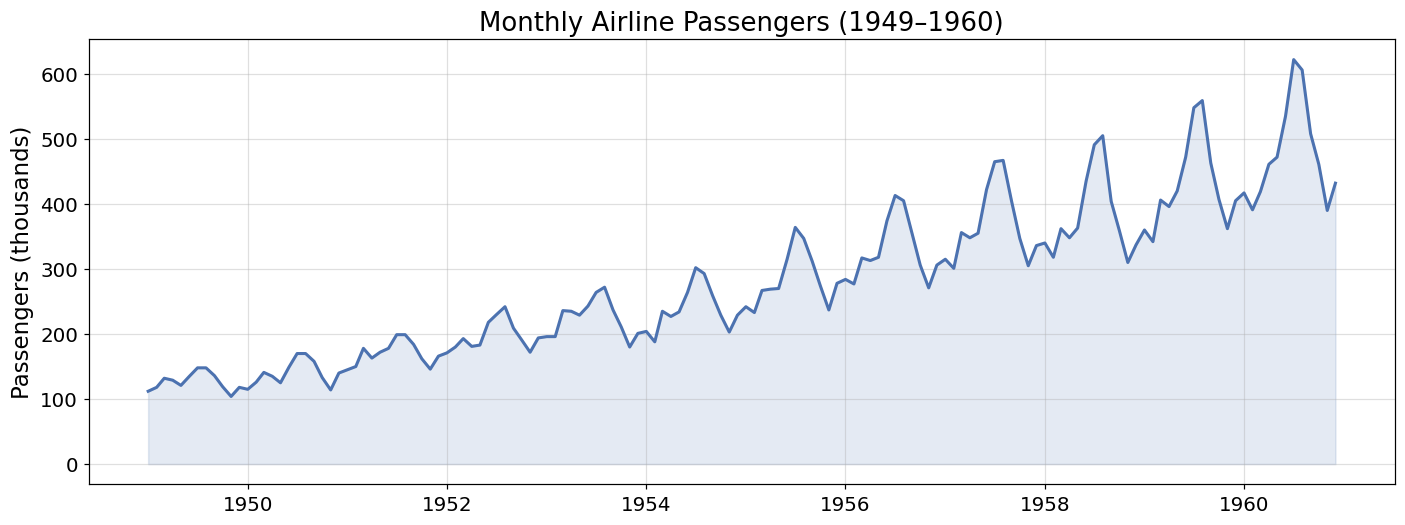

In [9]:
# Full time series
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df['Passengers'],color=C[0], linewidth=2)
ax.fill_between(df.index, df['Passengers'], alpha=0.15, color=C[0])
ax.set_title('Monthly Airline Passengers (1949–1960)')
ax.set_ylabel('Passengers (thousands)')
plt.tight_layout()
plt.show()

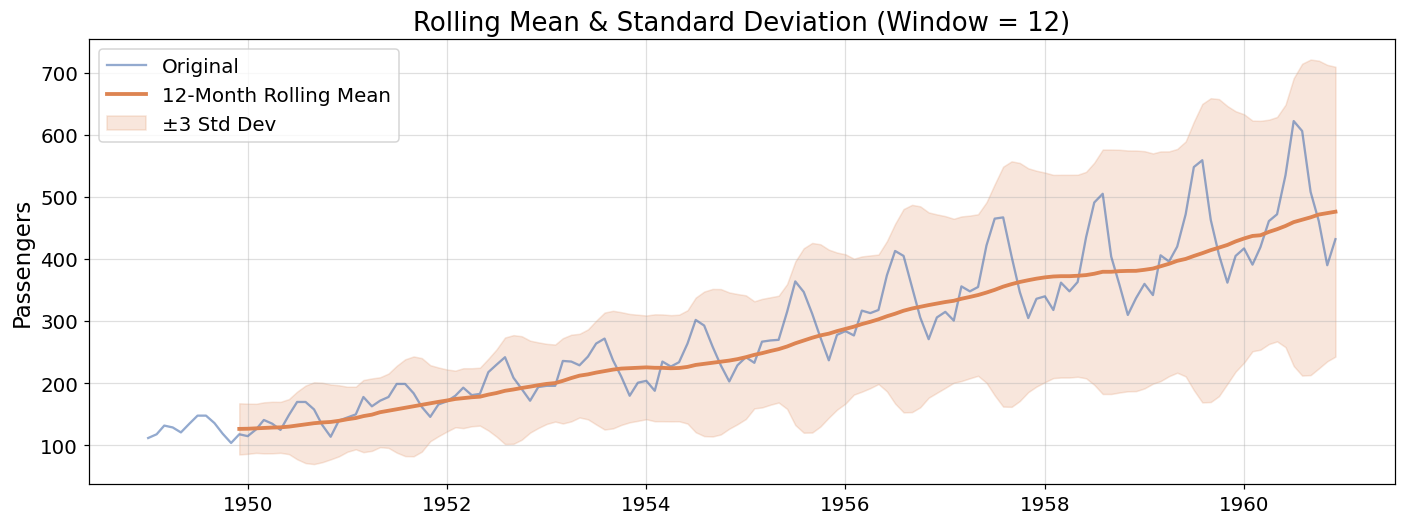

In [11]:
# Rolling mean and standard deviation
roll = df['Passengers'].rolling(12)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df['Passengers'],  color=C[0], linewidth=1.5, alpha=0.6, label='Original')
ax.plot(df.index, roll.mean(),       color=C[1], linewidth=2.5, label='12-Month Rolling Mean')
ax.fill_between(df.index, roll.mean()-3*roll.std(), roll.mean()+3*roll.std(),
                alpha=0.2, color=C[1], label='±3 Std Dev')
ax.set_title('Rolling Mean & Standard Deviation (Window = 12)')
ax.set_ylabel('Passengers')
ax.legend()
plt.tight_layout()
plt.show()

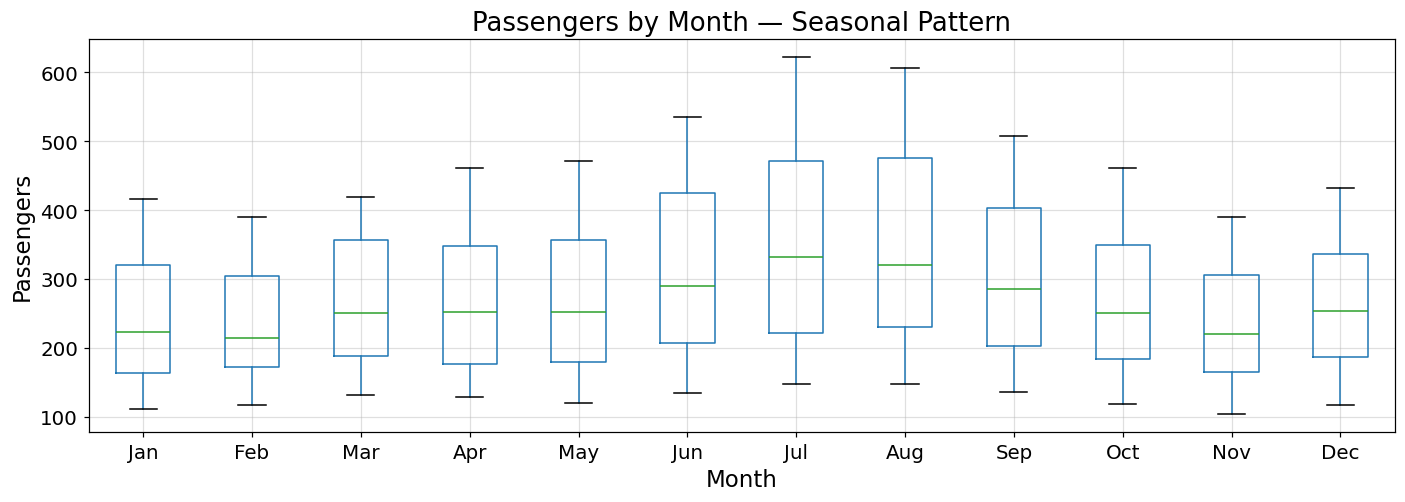

In [12]:
# Monthly box plot — seasonal pattern
df['Month_name'] = df.index.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['Month_name'] = pd.Categorical(df['Month_name'], categories=month_order, ordered=True)

fig, ax = plt.subplots(figsize=(13, 5))
df.boxplot(column='Passengers', by='Month_name', ax=ax)
ax.set_title('Passengers by Month — Seasonal Pattern')
ax.set_xlabel('Month')
ax.set_ylabel('Passengers')
plt.suptitle('')
plt.tight_layout()
plt.show()

df.drop(columns=['Month_name'], inplace=True)

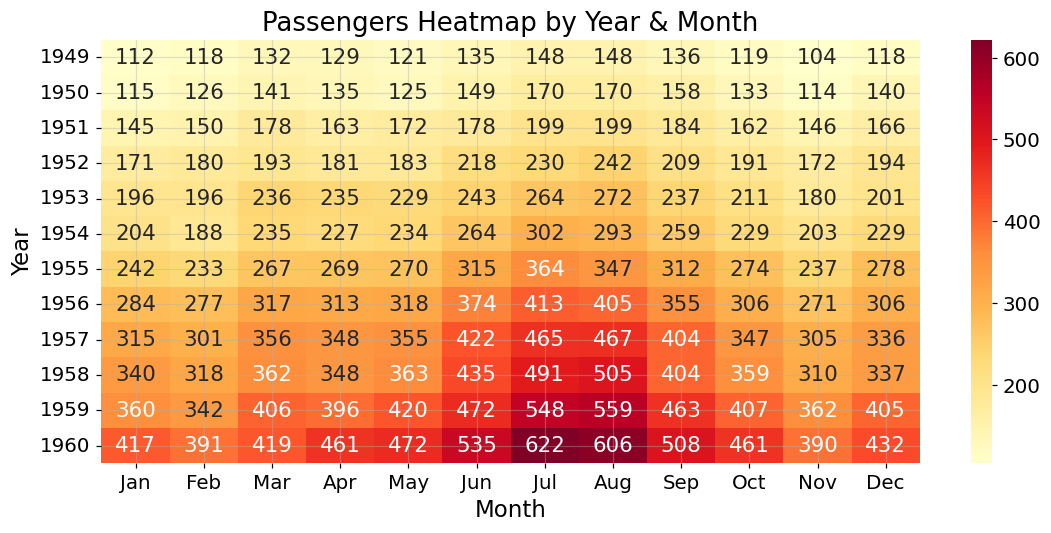

In [13]:
temp = df.copy()

# Extract year and month
temp['Year'] = temp.index.year
temp['Month_Num'] = temp.index.month

# Create Year × Month table
pivot = temp.pivot_table(
    values='Passengers',
    index='Year',
    columns='Month_Num'
)

# Month names
pivot.columns = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

# Heatmap
plt.figure(figsize=(12, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('Passengers Heatmap by Year & Month')
plt.xlabel('Month')
plt.ylabel('Year')

plt.show()

Line plot → How does the series change over time?
Monthly box plot → Which months are typically high/low across years?
Heatmap → Where are high/low values across both months AND years?

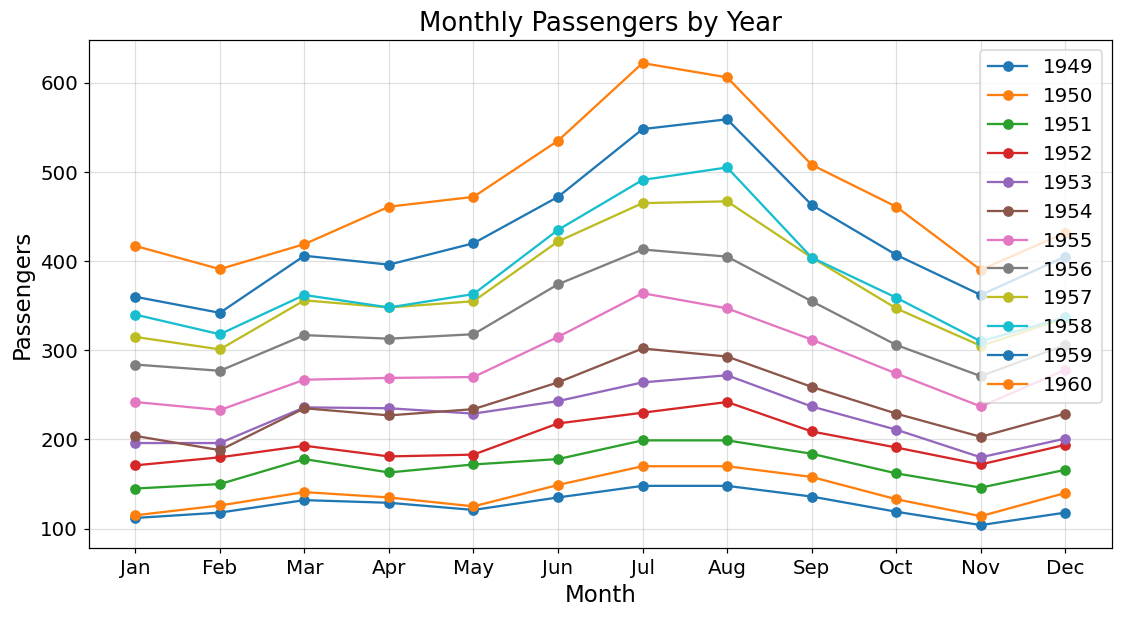

In [ ]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 6))

years = df.index.year.unique()

for year in years:

    vals = df[df.index.year == year]['Passengers'].values

    ax.plot(
        months,
        vals,
        marker='o',
        label=str(year)
    )

ax.set_title('Monthly Passengers by Year')
ax.set_xlabel('Month')
ax.set_ylabel('Passengers')

ax.legend()

plt.show()

## 4. Decomposition

- **Additive:** y = Trend + Seasonal + Residual  
- **Multiplicative:** y = Trend × Seasonal × Residual  
AirPassengers has growing seasonal swings → use **Multiplicative**.

As the data grows, does the size of the seasonal fluctuation also grow?

If NO → Additive
If YES → Multiplicative

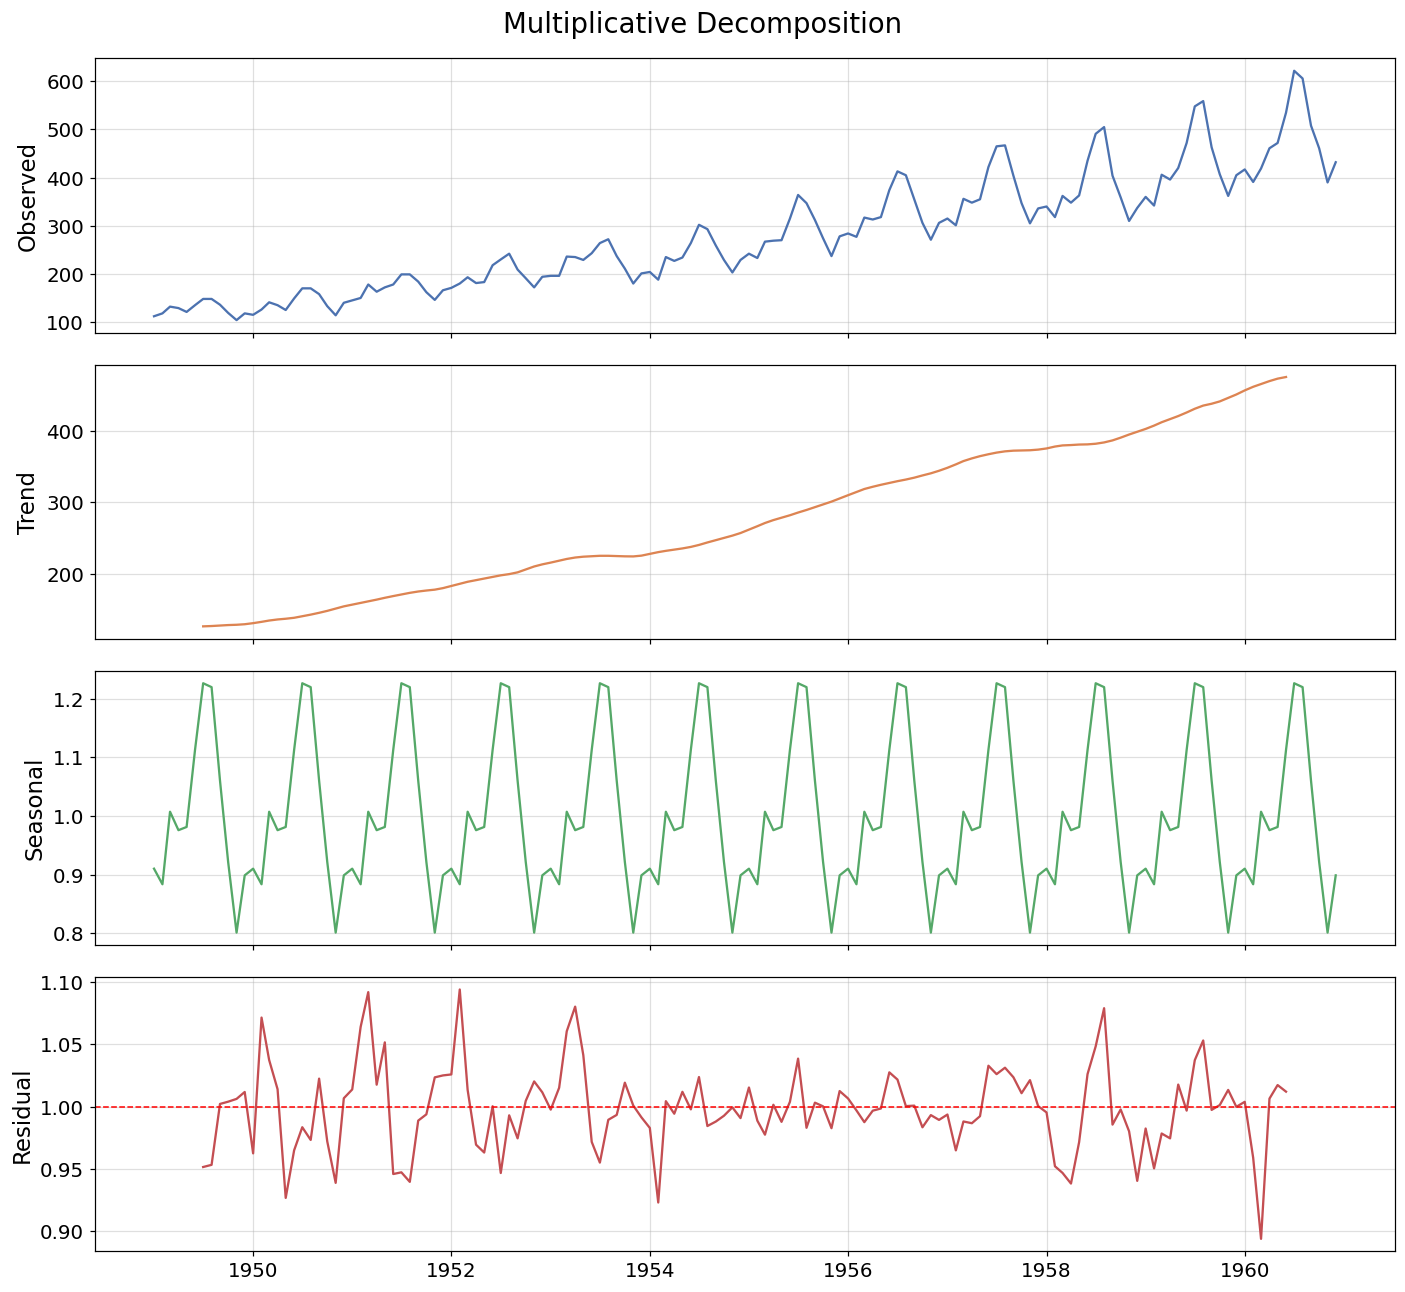

In [ ]:
# Multiplicative decomposition
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
fig.suptitle('Multiplicative Decomposition', fontsize=18)

axes[0].plot(df.index, result.observed,  color=C[0]); axes[0].set_ylabel('Observed')
axes[1].plot(df.index, result.trend,     color=C[1]); axes[1].set_ylabel('Trend')
axes[2].plot(df.index, result.seasonal,  color=C[2]); axes[2].set_ylabel('Seasonal')
axes[3].plot(df.index, result.resid,     color=C[3]); axes[3].set_ylabel('Residual')
axes[3].axhline(1, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

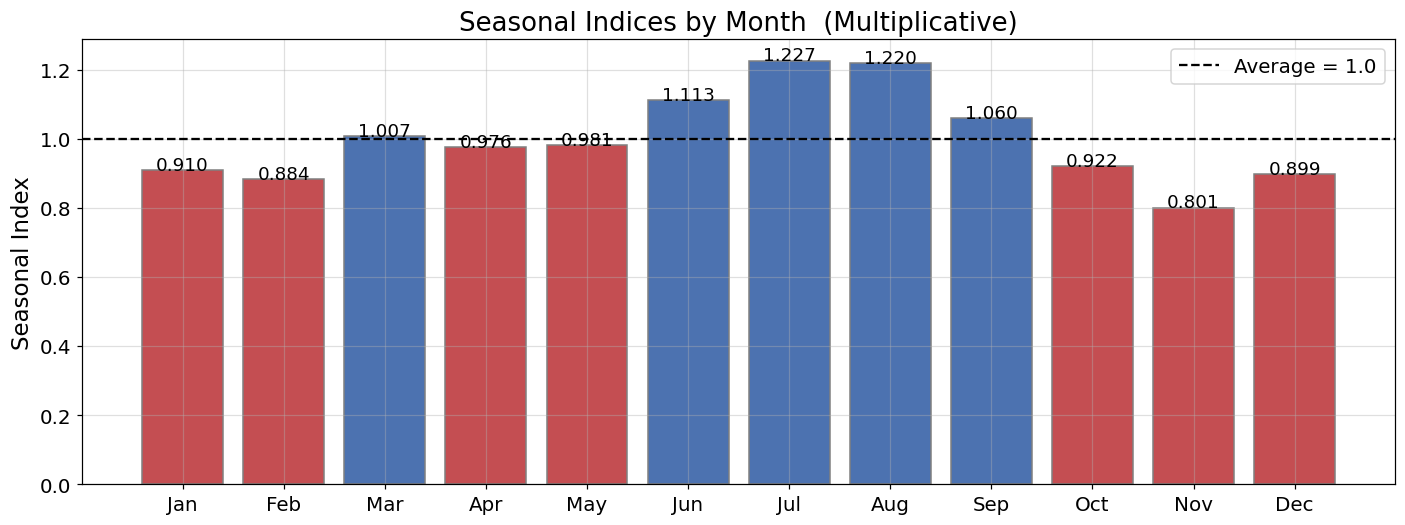

In [ ]:
# Seasonal indices bar chart
si = result.seasonal[:12].copy()
si.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 5))
colors = [C[3] if v < 1 else C[0] for v in si.values]
ax.bar(si.index, si.values, color=colors, edgecolor='grey')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Average = 1.0')

for i, (month, val) in enumerate(si.items()):
    ax.text(i, val , f'{val:.3f}', ha='center', fontsize=12)

ax.set_title('Seasonal Indices by Month  (Multiplicative)')
ax.set_ylabel('Seasonal Index')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Stationarity Tests

- **ADF Augmented Dickey-Fuller Test.:** H₀ = non-stationary. Reject if p < 0.05 → stationary
Unit root exists
      ↓
Shock effect can persist
      ↓
Non-stationary
- **KPSS:** H₀ = stationary. Reject if p < 0.05 → non-stationary

In [ ]:
def check_stationarity(series, name):
    adf_p  = adfuller(series.dropna(), autolag='AIC')[1]
    kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]

    adf_result  = 'STATIONARY'     if adf_p  < 0.05 else 'NON-STATIONARY'
    kpss_result = 'NON-STATIONARY' if kpss_p < 0.05 else 'STATIONARY'

    print(f'--- {name} ---')
    print(f'  ADF  p={adf_p:.4f}  → {adf_result}')
    print(f'  KPSS p={kpss_p:.4f}  → {kpss_result}')
    print()

check_stationarity(df['Passengers'], 'Original Series')

--- Original Series ---
  ADF  p=0.9919  → NON-STATIONARY
  KPSS p=0.0100  → NON-STATIONARY



## 6. Make the Series Stationary

**Steps:**
1. Log transform → stabilizes variance
2. Seasonal diff (lag=12) → removes seasonality
3. First diff (lag=1) → removes trend

In [ ]:
df['log']      = np.log(df['Passengers'])
df['log_d12']  = df['log'].diff(12)
df['log_d12_d1'] = df['log_d12'].diff(1)

# Check stationarity at each step
check_stationarity(df['log'],        'Log')
check_stationarity(df['log_d12'],    'Log + Seasonal Diff(12)')
check_stationarity(df['log_d12_d1'],'Log + Diff(12) + Diff(1)')

--- Log ---
  ADF  p=0.4224  → NON-STATIONARY
  KPSS p=0.0100  → NON-STATIONARY

--- Log + Seasonal Diff(12) ---
  ADF  p=0.0724  → NON-STATIONARY
  KPSS p=0.1000  → STATIONARY

--- Log + Diff(12) + Diff(1) ---
  ADF  p=0.0002  → STATIONARY
  KPSS p=0.1000  → STATIONARY



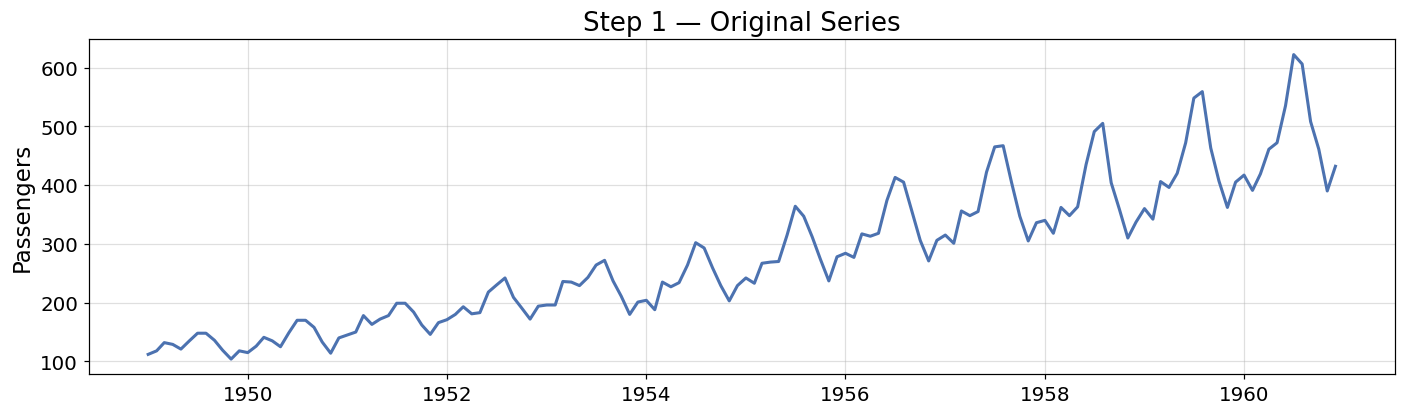

In [ ]:
# Plot: Original
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['Passengers'], color=C[0], linewidth=2)
ax.set_title('Step 1 — Original Series')
ax.set_ylabel('Passengers')
plt.tight_layout()
plt.show()

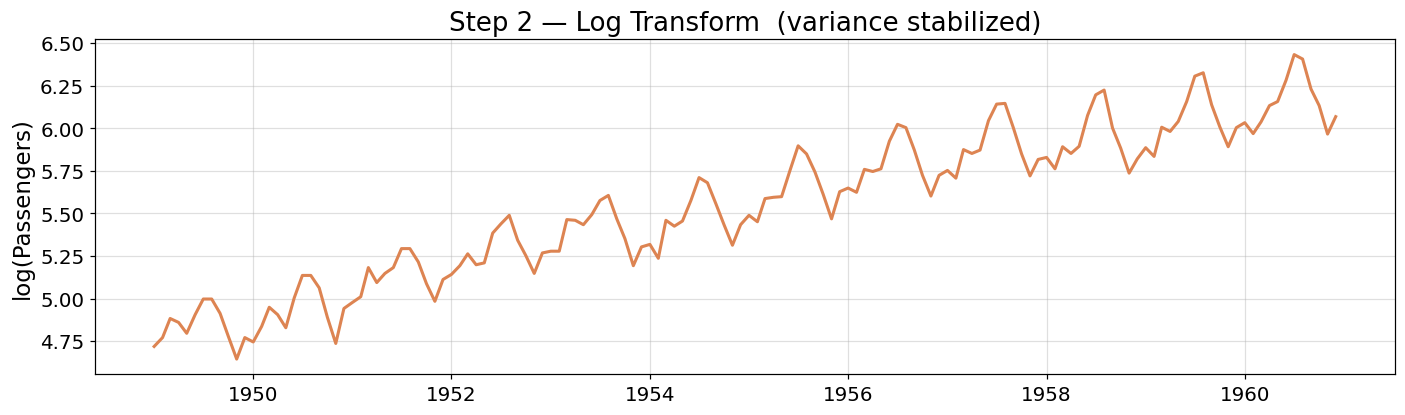

In [ ]:
# Plot: Log Transform
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['log'], color=C[1], linewidth=2)
ax.set_title('Step 2 — Log Transform  (variance stabilized)')
ax.set_ylabel('log(Passengers)')
plt.tight_layout()
plt.show()

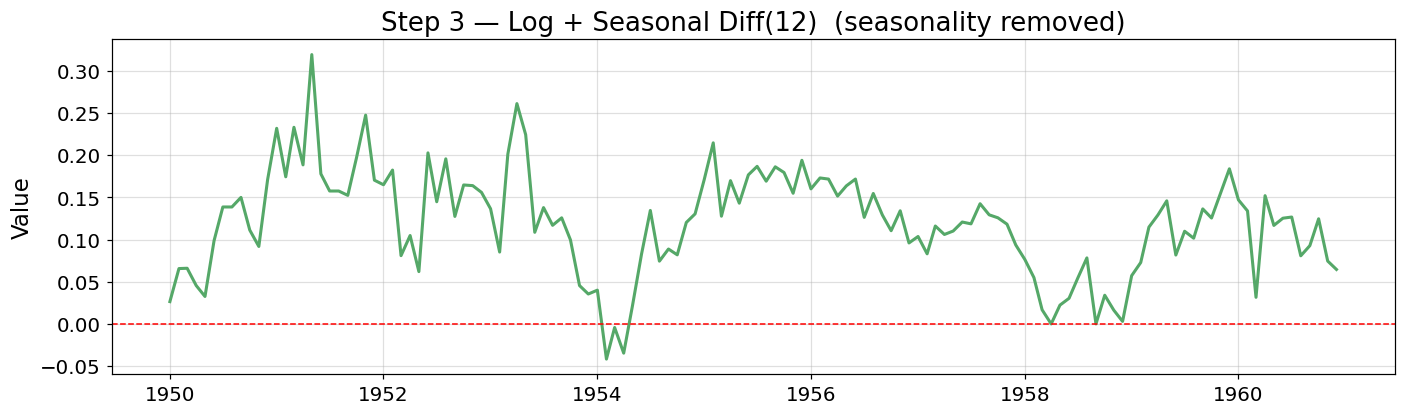

In [ ]:
# Plot: Log + Seasonal Diff
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['log_d12'], color=C[2], linewidth=2)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Step 3 — Log + Seasonal Diff(12)  (seasonality removed)')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

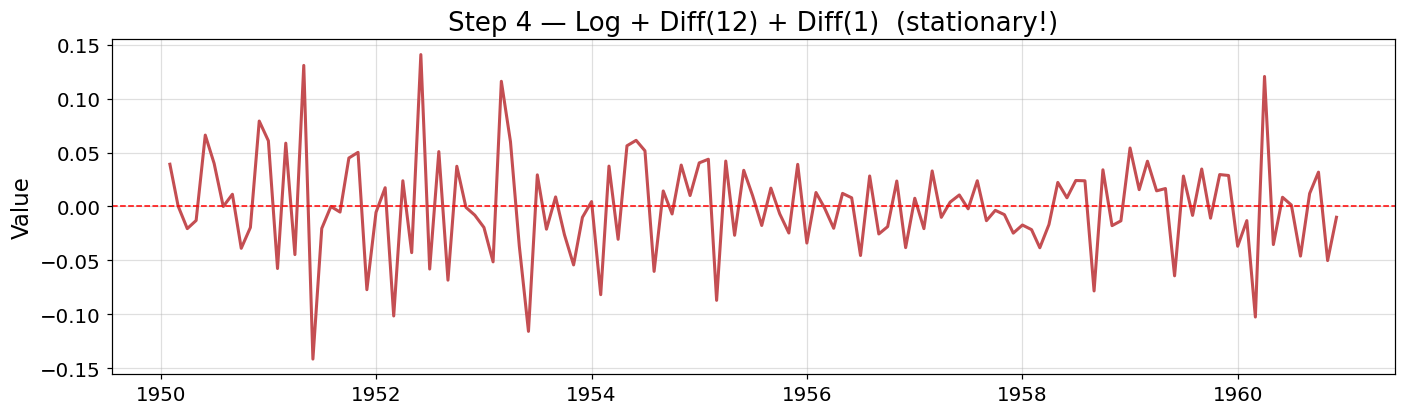

In [ ]:
# Plot: Fully Stationary
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['log_d12_d1'], color=C[3], linewidth=2)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Step 4 — Log + Diff(12) + Diff(1)  (stationary!)')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

## 7. ACF & PACF

- ACF cuts off at lag q → MA(q)
- PACF cuts off at lag p → AR(p)

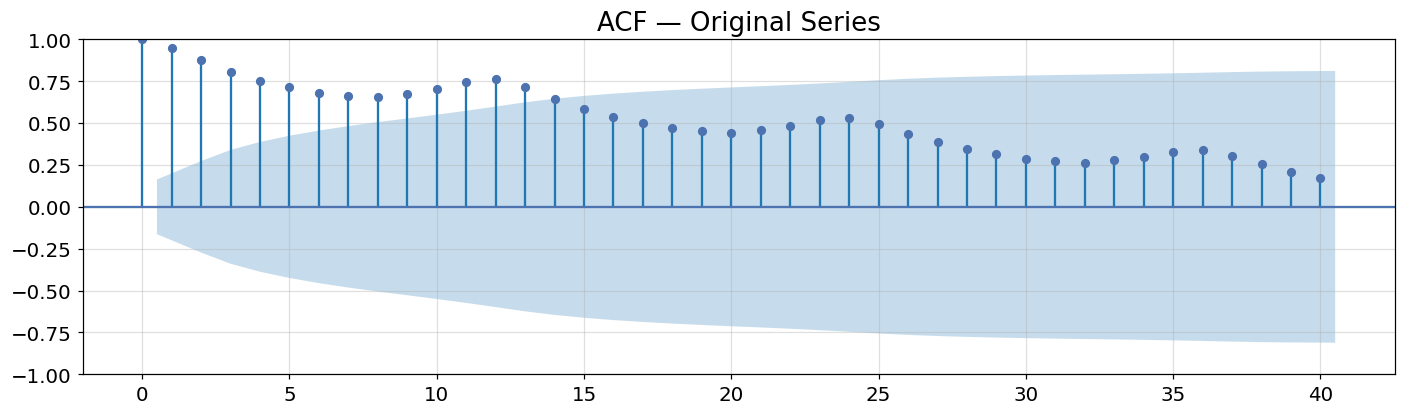

In [ ]:
# ACF — Original Series
fig, ax = plt.subplots(figsize=(13, 4))
plot_acf(df['Passengers'], lags=40, ax=ax, color=C[0])
ax.set_title('ACF — Original Series')
plt.tight_layout()
plt.show()

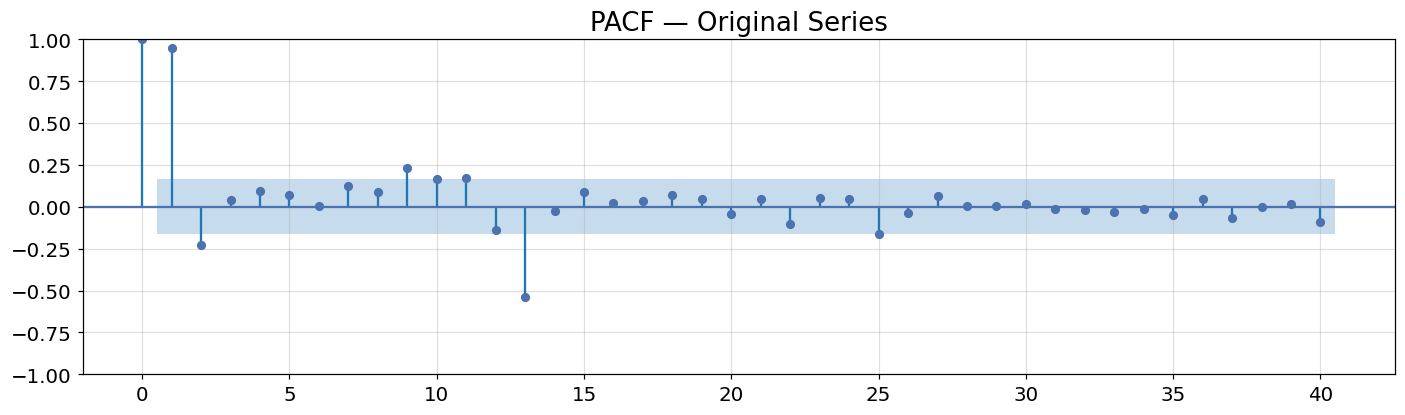

In [ ]:
# PACF — Original Series
fig, ax = plt.subplots(figsize=(13, 4))
plot_pacf(df['Passengers'], lags=40, ax=ax, method='ywm', color=C[0])
ax.set_title('PACF — Original Series')
plt.tight_layout()
plt.show()

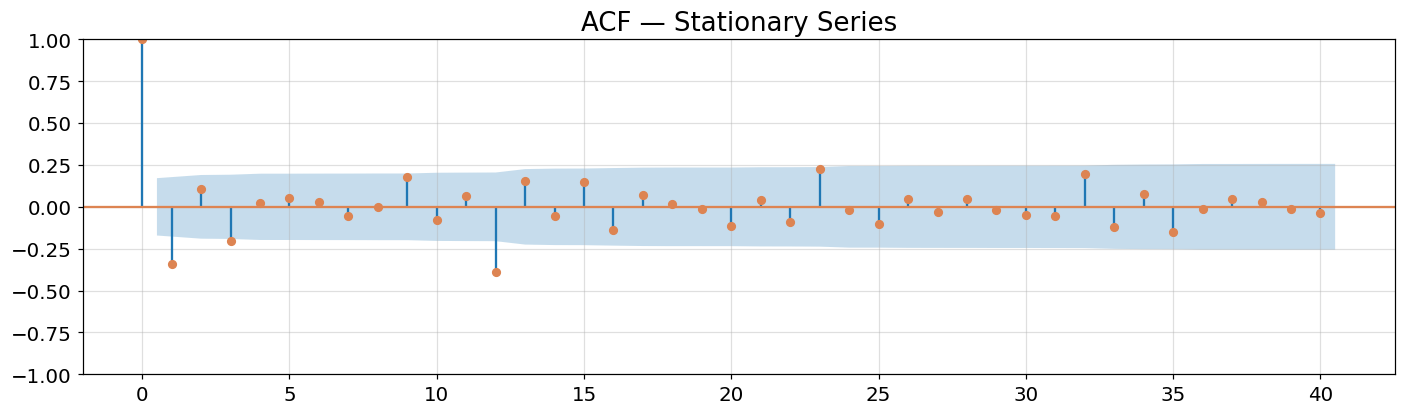

In [ ]:
# ACF — Stationary Series
stationary = df['log_d12_d1'].dropna()

fig, ax = plt.subplots(figsize=(13, 4))
plot_acf(stationary, lags=40, ax=ax, color=C[1])
ax.set_title('ACF — Stationary Series')
plt.tight_layout()
plt.show()

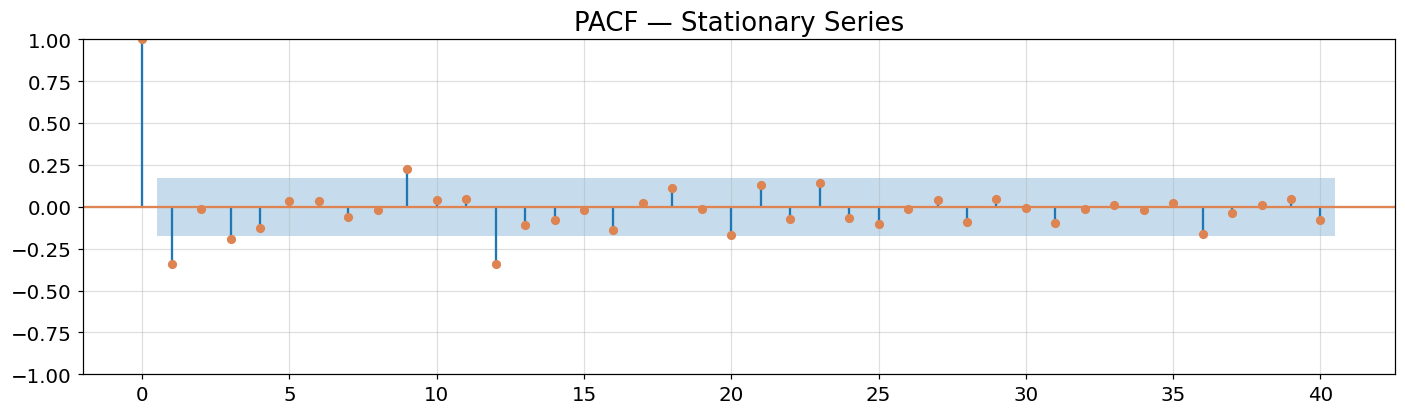

In [ ]:
# PACF — Stationary Series
fig, ax = plt.subplots(figsize=(13, 4))
plot_pacf(stationary, lags=40, ax=ax, method='ywm', color=C[1])
ax.set_title('PACF — Stationary Series')
plt.tight_layout()
plt.show()

## 8. Train-Test Split & Smoothing

In [ ]:
train = df['Passengers'][:'1958-12']
test  = df['Passengers']['1959-01':]
print(f'Train: {len(train)} months  ({train.index[0].date()} to {train.index[-1].date()})')
print(f'Test : {len(test)} months  ({test.index[0].date()} to {test.index[-1].date()})')

results = {}   # will store all model scores

def score(name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    results[name] = {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(mape,2)}
    print(f'{name:<30}  MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.2f}%')

Train: 120 months  (1949-01-01 to 1958-12-01)
Test : 24 months  (1959-01-01 to 1960-12-01)


In [ ]:
# Fit smoothing models
ses  = SimpleExpSmoothing(train).fit(optimized=True)
holt = ExponentialSmoothing(train, trend='add').fit(optimized=True)
hw_a = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
hw_m = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit(optimized=True)

ses_pred  = pd.Series(ses.forecast(len(test)),  index=test.index)
holt_pred = pd.Series(holt.forecast(len(test)), index=test.index)
hw_a_pred = pd.Series(hw_a.forecast(len(test)), index=test.index)
hw_m_pred = pd.Series(hw_m.forecast(len(test)), index=test.index)

score('Simple Exp Smoothing',       test, ses_pred)
score('Holt Linear',                test, holt_pred)
score('Holt-Winters Additive',      test, hw_a_pred)
score('Holt-Winters Multiplicative',test, hw_m_pred)

Simple Exp Smoothing            MAE=115.3  RMSE=137.3  MAPE=23.58%
Holt Linear                     MAE=91.6  RMSE=115.7  MAPE=18.41%
Holt-Winters Additive           MAE=31.1  RMSE=35.8  MAPE=6.64%
Holt-Winters Multiplicative     MAE=29.0  RMSE=32.5  MAPE=6.39%


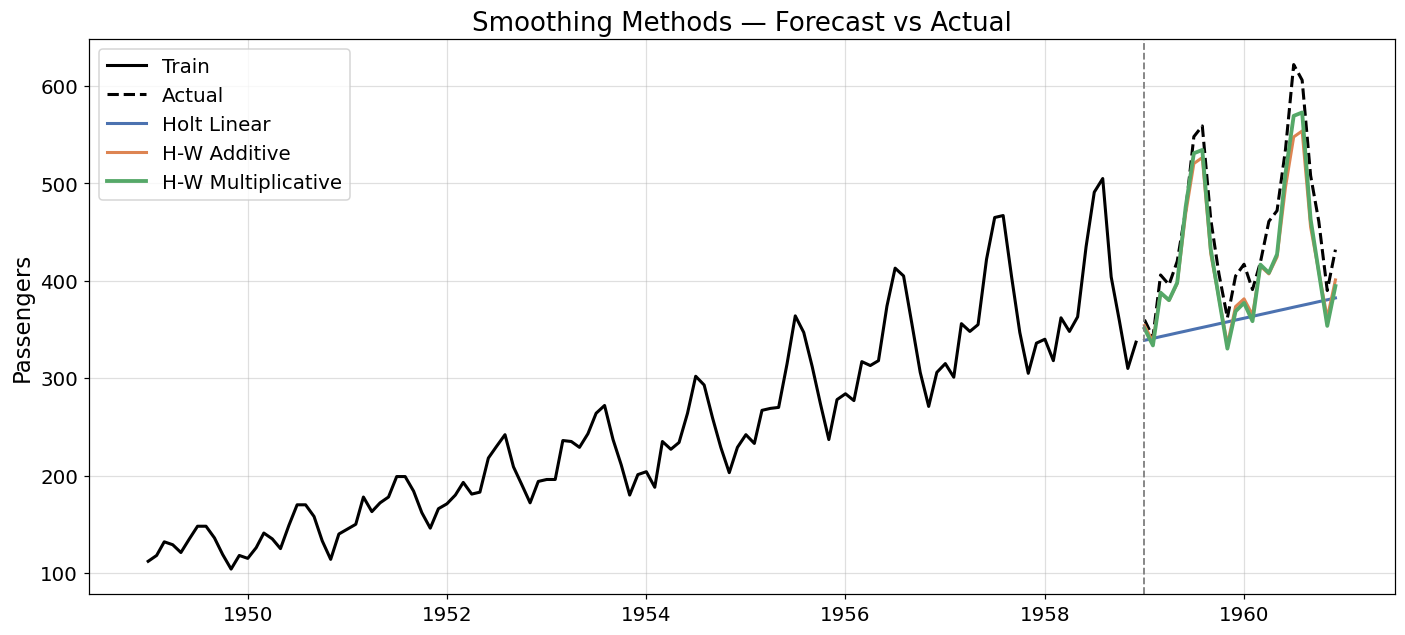

In [ ]:
# Smoothing forecast comparison
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index, train,     color='black',  linewidth=2,   label='Train')
ax.plot(test.index,  test,      color='black',  linewidth=2,   label='Actual', linestyle='--')
ax.plot(test.index,  holt_pred, color=C[0],     linewidth=2,   label='Holt Linear')
ax.plot(test.index,  hw_a_pred, color=C[1],     linewidth=2,   label='H-W Additive')
ax.plot(test.index,  hw_m_pred, color=C[2],     linewidth=2.5, label='H-W Multiplicative')
ax.axvline(pd.Timestamp('1959-01'), color='grey', linestyle='--', linewidth=1.2)
ax.set_title('Smoothing Methods — Forecast vs Actual')
ax.set_ylabel('Passengers')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
#AIC=2k−2ln(L)

## 9. ARIMA

ARIMA(p, d, q): **p** = AR lags, **d** = differencing, **q** = MA lags

In [ ]:
log_train = np.log(train)
log_test  = np.log(test)

# Manual ARIMA
arima = ARIMA(log_train, order=(2, 1, 1)).fit()
arima_pred = pd.Series(np.exp(arima.forecast(len(test))), index=test.index)
score('ARIMA(2,1,1)', test, arima_pred)

# Auto ARIMA
print('\nRunning auto_arima...')
best_arima = pm.auto_arima(log_train, seasonal=False, stepwise=True,
                            error_action='ignore', trace=True)
auto_arima_pred = pd.Series(np.exp(best_arima.predict(len(test))), index=test.index)
print(f'\nBest order: {best_arima.order}')
score(f'auto_ARIMA{best_arima.order}', test, auto_arima_pred)

ARIMA(2,1,1)                    MAE=81.9  RMSE=107.8  MAPE=16.26%

Running auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-193.784, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-195.846, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-197.533, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-194.869, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-200.484, Time=0.20 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.47 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-197.689, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-201.680, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-198.889, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-197.184, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0]       

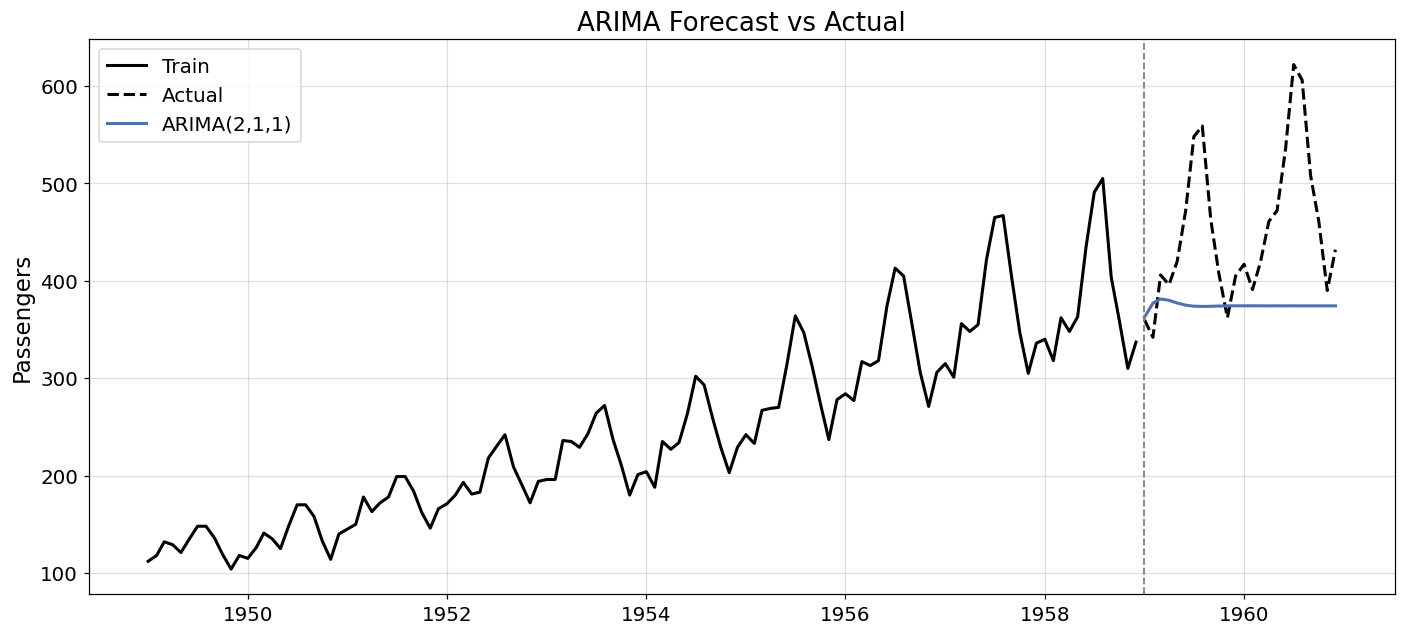

In [ ]:
# ARIMA forecast plot
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index, train,       color='black', linewidth=2, label='Train')
ax.plot(test.index,  test,        color='black', linewidth=2, label='Actual', linestyle='--')
ax.plot(test.index,  arima_pred,  color=C[0],    linewidth=2, label='ARIMA(2,1,1)')
ax.axvline(pd.Timestamp('1959-01'), color='grey', linestyle='--', linewidth=1.2)
ax.set_title('ARIMA Forecast vs Actual')
ax.set_ylabel('Passengers')
ax.legend()
plt.tight_layout()
plt.show()

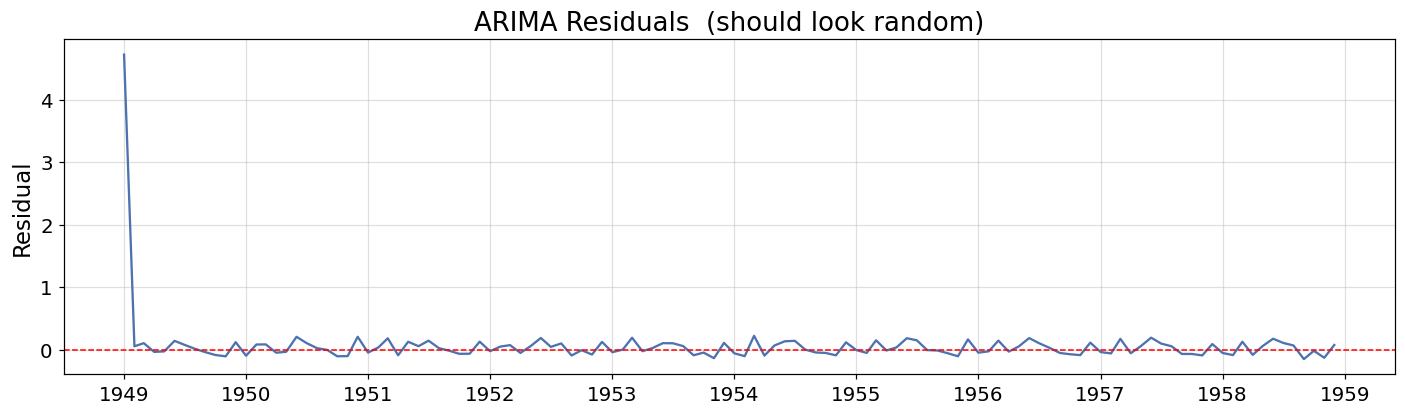

In [ ]:
# ARIMA residuals
residuals = arima.resid

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(residuals, color=C[0], linewidth=1.5)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('ARIMA Residuals  (should look random)')
ax.set_ylabel('Residual')
plt.tight_layout()
plt.show()

## 10. SARIMA

SARIMA(p,d,q)(P,D,Q)[m] — adds seasonal AR, differencing, MA terms.  
For AirPassengers: **(1,1,1)(0,1,1)[12]**

In [ ]:
sarima = SARIMAX(log_train, order=(1,1,1), seasonal_order=(0,1,1,12)).fit(disp=False)
sarima_pred = pd.Series(np.exp(sarima.forecast(len(test))), index=test.index)
score('SARIMA(1,1,1)(0,1,1)[12]', test, sarima_pred)

# Auto SARIMA
print('\nRunning auto_arima (seasonal)...')
best_sarima = pm.auto_arima(log_train, seasonal=True, m=12, d=1, D=1,
                             stepwise=True, error_action='ignore', trace=True)
auto_sarima_pred = pd.Series(np.exp(best_sarima.predict(len(test))), index=test.index)
print(f'\nBest: {best_sarima.order} × {best_sarima.seasonal_order}')
score('auto_SARIMA', test, auto_sarima_pred)

SARIMA(1,1,1)(0,1,1)[12]        MAE=36.1  RMSE=39.8  MAPE=7.79%

Running auto_arima (seasonal)...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=-383.314, Time=3.56 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-353.412, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-383.359, Time=0.52 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-389.010, Time=1.23 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-364.326, Time=0.15 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-387.220, Time=1.02 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-387.254, Time=2.39 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-384.232, Time=0.50 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=3.96 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-379.989, Time=0.34 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-387.279, Time=1.36 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=-387.065, Time=1.12 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-388.643, Time=0.

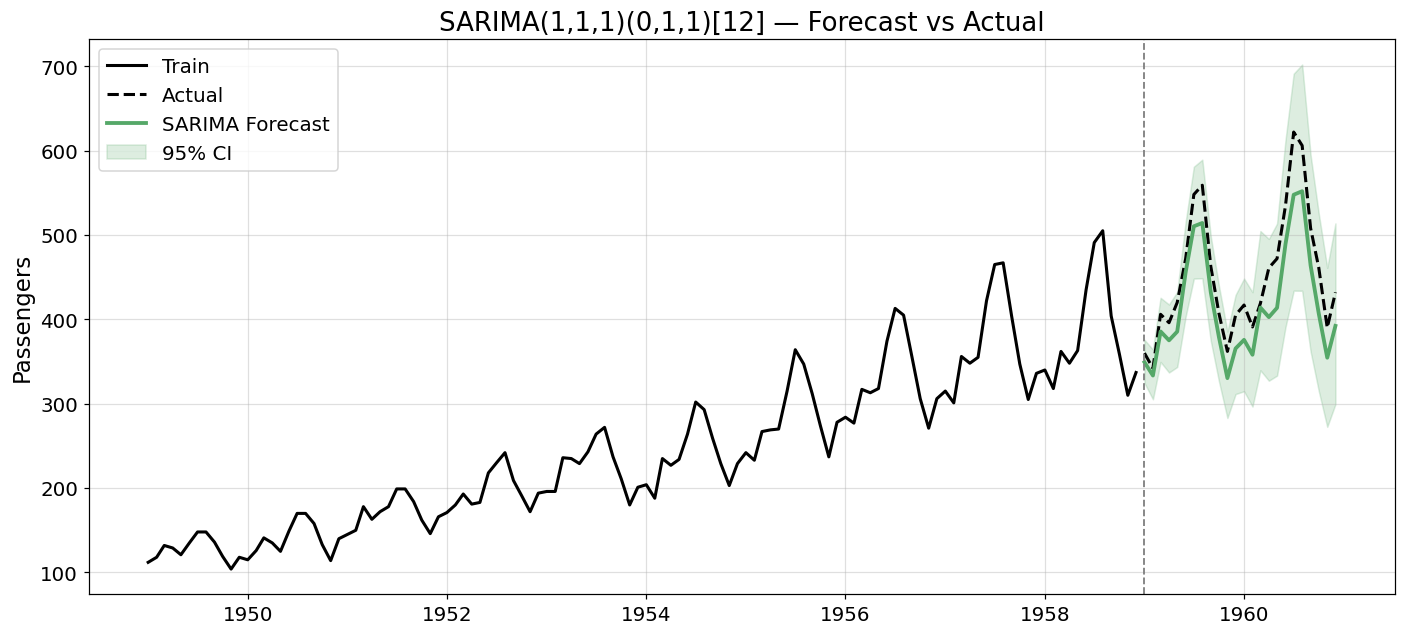

In [ ]:
# SARIMA forecast with confidence interval
fc = sarima.get_forecast(steps=len(test))
fc_mean = np.exp(fc.predicted_mean)
fc_ci   = np.exp(fc.conf_int(alpha=0.05))

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index, train,           color='black', linewidth=2,   label='Train')
ax.plot(test.index,  test,            color='black', linewidth=2,   label='Actual', linestyle='--')
ax.plot(fc_mean.index, fc_mean.values,color=C[2],    linewidth=2.5, label='SARIMA Forecast')
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                alpha=0.2, color=C[2], label='95% CI')
ax.axvline(pd.Timestamp('1959-01'), color='grey', linestyle='--', linewidth=1.2)
ax.set_title('SARIMA(1,1,1)(0,1,1)[12] — Forecast vs Actual')
ax.set_ylabel('Passengers')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Feature Engineering for ML

In [ ]:
def make_features(series):
    d = pd.DataFrame({'Passengers': series})
    d['month']     = d.index.month
    d['year']      = d.index.year
    d['month_sin'] = np.sin(2 * np.pi * d.index.month / 12)
    d['month_cos'] = np.cos(2 * np.pi * d.index.month / 12)
    d['trend']     = (d.index.year - 1949) / 11
    for lag in [1, 2, 3, 6, 12]:
        d[f'lag_{lag}'] = series.shift(lag)
    for w in [3, 6, 12]:
        s = series.shift(1)
        d[f'roll_mean_{w}'] = s.rolling(w).mean()
        d[f'roll_std_{w}']  = s.rolling(w).std()
    d['yoy'] = series / series.shift(12) - 1
    d['mom'] = series / series.shift(1)  - 1
    return d.dropna()

df_ml = make_features(df['Passengers'])
print('Feature shape:', df_ml.shape)
print('Features:', [c for c in df_ml.columns if c != 'Passengers'])

Feature shape: (132, 19)
Features: ['month', 'year', 'month_sin', 'month_cos', 'trend', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'yoy', 'mom']


## 12. XGBoost & LightGBM

In [ ]:
FEATS  = [c for c in df_ml.columns if c != 'Passengers']
ml_tr  = df_ml[df_ml.index <= '1958-12']
ml_te  = df_ml[df_ml.index >= '1959-01']
Xtr, ytr = ml_tr[FEATS], ml_tr['Passengers']
Xte, yte = ml_te[FEATS], ml_te['Passengers']

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                               random_state=42, verbosity=0)
xgb_model.fit(Xtr, ytr)
xgb_pred = pd.Series(xgb_model.predict(Xte), index=yte.index)

lgb_model = lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                random_state=42, verbose=-1)
lgb_model.fit(Xtr, ytr)
lgb_pred = pd.Series(lgb_model.predict(Xte), index=yte.index)

score('XGBoost',  yte, xgb_pred)
score('LightGBM', yte, lgb_pred)

XGBoost                         MAE=41.3  RMSE=52.2  MAPE=8.63%
LightGBM                        MAE=52.6  RMSE=70.7  MAPE=10.49%


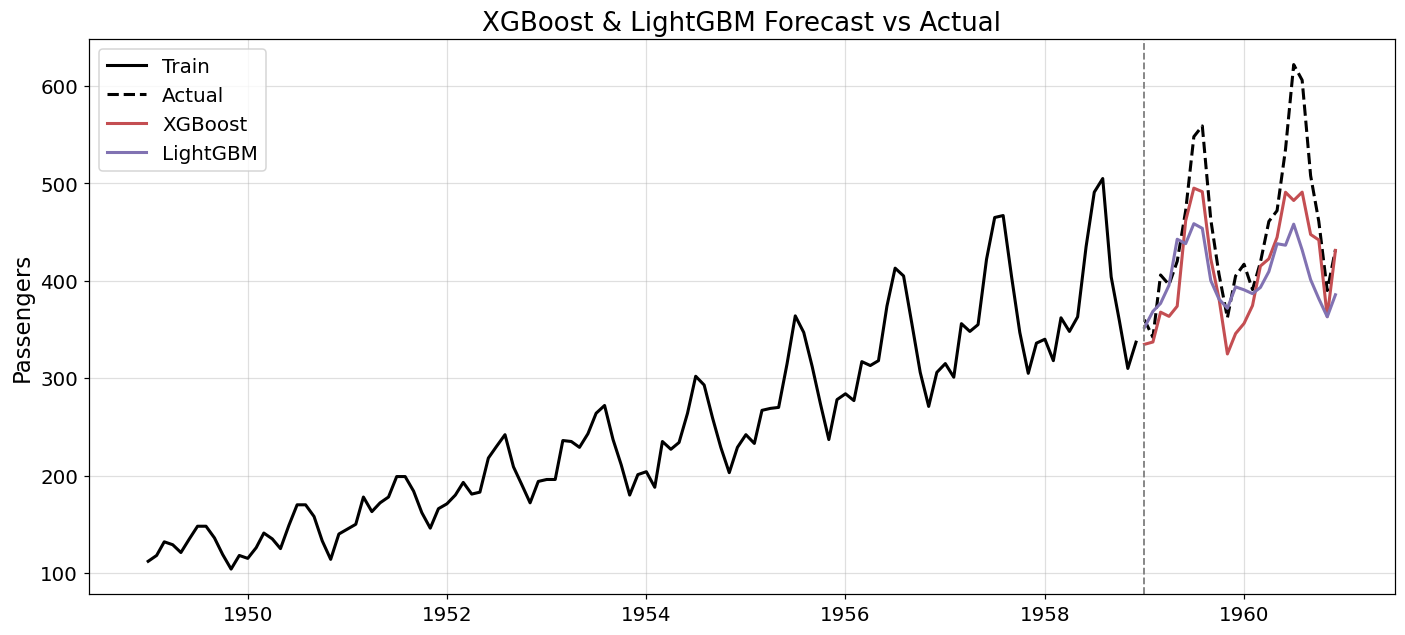

In [ ]:
# XGBoost & LightGBM forecast plot
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index, train,    color='black', linewidth=2, label='Train')
ax.plot(test.index,  test,     color='black', linewidth=2, label='Actual', linestyle='--')
ax.plot(yte.index,   xgb_pred, color=C[3],   linewidth=2, label='XGBoost')
ax.plot(yte.index,   lgb_pred, color=C[4],   linewidth=2, label='LightGBM')
ax.axvline(pd.Timestamp('1959-01'), color='grey', linestyle='--', linewidth=1.2)
ax.set_title('XGBoost & LightGBM Forecast vs Actual')
ax.set_ylabel('Passengers')
ax.legend()
plt.tight_layout()
plt.show()

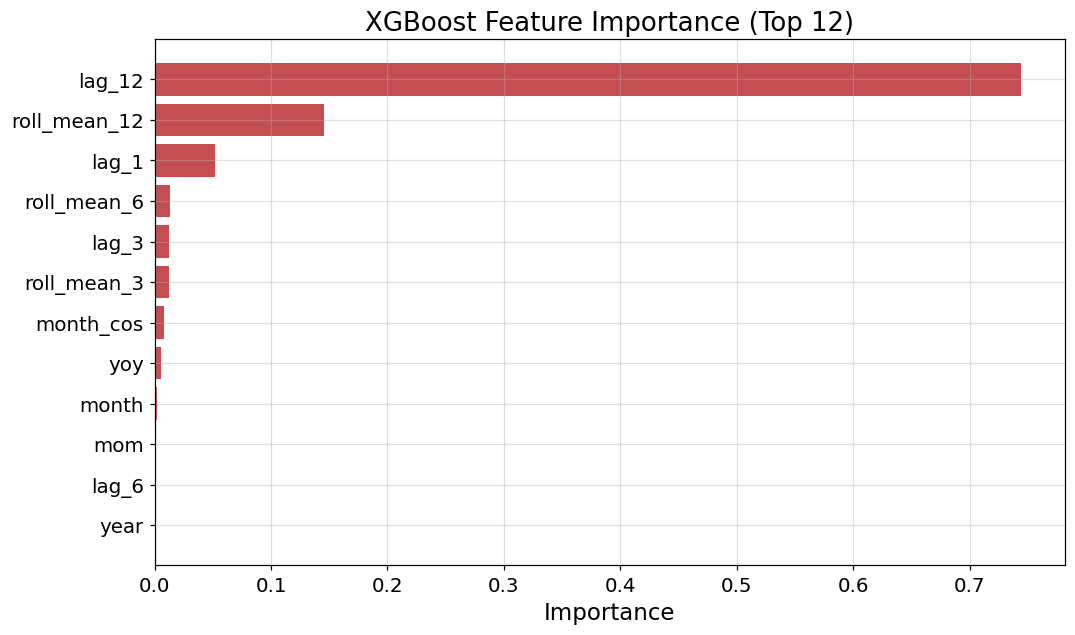

In [ ]:
# Feature importance — XGBoost (top 12)
fi = pd.Series(xgb_model.feature_importances_, index=FEATS).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi.index, fi.values, color=C[3])
ax.set_title('XGBoost Feature Importance (Top 12)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 13. LSTM

LSTM captures long-range patterns in sequences.  
Sequence length = 12 months lookback.

In [ ]:
try:
    import tensorflow as tf
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow', '-q'])
    import tensorflow as tf
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


In [ ]:
SEQ = 12
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df['Passengers'].values.reshape(-1,1)).flatten()

X_seq, y_seq = [], []
for i in range(len(scaled) - SEQ):
    X_seq.append(scaled[i:i+SEQ])
    y_seq.append(scaled[i+SEQ])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)

split = len(X_seq) - 24
Xtr_l, Xte_l = X_seq[:split].reshape(-1, SEQ, 1), X_seq[split:].reshape(-1, SEQ, 1)
ytr_l, yte_l = y_seq[:split], y_seq[split:]
print('LSTM train:', Xtr_l.shape, '  test:', Xte_l.shape)

LSTM train: (108, 12, 1)   test: (24, 12, 1)


                           AirPassengers Dataset
                     (144 Monthly Passenger Values)
                                      │
                                      ▼
                  df['Passengers'].values.reshape(-1,1)
                                      │
                                      ▼
                              MinMaxScaler()
                                      │
                                      ▼
                    Scaled Values (Between 0 and 1)
                                      │
                                      ▼
                            scaled = [0.02,0.05,...]
                                      │
                                      ▼
                        SEQ = 12 (Sliding Window)
                                      │
                                      ▼
        ┌─────────────────────────────────────────────────────┐
        │ Loop: for i in range(len(scaled)-12)                │
        │                                                     │
        │  Iteration 1                                        │
        │  X = [Month1 ............ Month12]                  │
        │  y = Month13                                        │
        │                                                     │
        │  Iteration 2                                        │
        │  X = [Month2 ............ Month13]                  │
        │  y = Month14                                        │
        │                                                     │
        │  Iteration 3                                        │
        │  X = [Month3 ............ Month14]                  │
        │  y = Month15                                        │
        │                                                     │
        │                     ...                             │
        │                                                     │
        │  Last Iteration                                     │
        │  X = Previous 12 Months                             │
        │  y = Next Month                                     │
        └─────────────────────────────────────────────────────┘
                                      │
                                      ▼
                  X_seq.append()          y_seq.append()
                                      │
                                      ▼
                      X_seq Shape = (132,12)
                      y_seq Shape = (132,)
                                      │
                                      ▼
                   Convert List → NumPy Array
                                      │
                                      ▼
                   split = len(X_seq) - 24
                          = 132 - 24
                          = 108
                                      │
                  ┌───────────────────┴───────────────────┐
                  ▼                                       ▼
          Training Data                           Testing Data
       X_seq[:108] , y_seq[:108]             X_seq[108:] , y_seq[108:]
                  │                                       │
                  ▼                                       ▼
       Shape = (108,12)                      Shape = (24,12)
                  │                                       │
                  ▼                                       ▼
          reshape(-1,12,1)                    reshape(-1,12,1)
                  │                                       │
                  ▼                                       ▼
      Xtr_l Shape = (108,12,1)              Xte_l Shape = (24,12,1)
                  │                                       │
                  └───────────────────┬───────────────────┘
                                      ▼
                     Ready to Feed into LSTM Network

In [ ]:
from tensorflow.keras import layers, models, callbacks
tf.random.set_seed(42)

model = models.Sequential([
    layers.Input(shape=(SEQ, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(
    Xtr_l, ytr_l,
    epochs=150, batch_size=8,
    validation_split=0.1,
    callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)],
    shuffle=False, verbose=1
)
print('Stopped at epoch', len(history.history['loss']))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 12, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0194 - val_loss: 0.0211
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0161 - val_loss: 0.0250
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0071 - val_loss: 0.0176
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0066 - val_loss: 0.0176
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0062 - val_loss: 0.0175
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0062 - val_loss: 0.0173
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0058 - val_loss: 0.0171
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0060 - val_loss: 0.0169
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0062 - val_loss: 0.0168
Epoch 10/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0061 - val_loss: 0.0165
Epoch 11/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0055 - val_loss: 0.0166
Epoch 12/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

                         Training Data
                     Xtr_l Shape = (108,12,1)
                (108 Samples, 12 Time Steps, 1 Feature)
                                │
                                ▼
                  ┌─────────────────────────────┐
                  │        Input Layer          │
                  │      Shape = (12,1)         │
                  └─────────────────────────────┘
                                │
                                ▼
                  ┌─────────────────────────────┐
                  │      LSTM Layer - 1         │
                  │      64 Memory Cells        │
                  │ return_sequences = True     │
                  │                             │
                  │ Output Shape: (12,64)       │
                  └─────────────────────────────┘
                                │
                                ▼
                  ┌─────────────────────────────┐
                  │       Dropout Layer         │
                  │        Rate = 0.20          │
                  │ (Randomly drops 20% neurons)│
                  │                             │
                  │ Output Shape: (12,64)       │
                  └─────────────────────────────┘
                                │
                                ▼
                  ┌─────────────────────────────┐
                  │      LSTM Layer - 2         │
                  │      32 Memory Cells        │
                  │ return_sequences = False    │
                  │                             │
                  │ Output Shape: (32)          │
                  └─────────────────────────────┘
                                │
                                ▼
                  ┌─────────────────────────────┐
                  │        Dense Layer          │
                  │         1 Neuron            │
                  │  Predict Next Passenger     │
                  │                             │
                  │ Output Shape: (1)           │
                  └─────────────────────────────┘
                                │
                                ▼
                    Predicted Passenger Value

                 12 Months
                     │
                     ▼
     ┌──────────────────────────────────────┐
     │        LSTM Layer (64 Units)         │
     ├──────────────────────────────────────┤
     │ Unit 1  → Learns Trend               │
     │ Unit 2  → Learns Seasonality         │
     │ Unit 3  → Learns Sudden Increase     │
     │ Unit 4  → Learns Sudden Drop         │
     │ Unit 5  → Learns Long-term Growth    │
     │ ...                                 │
     │ Unit 64 → Learns Another Pattern     │
     └──────────────────────────────────────┘

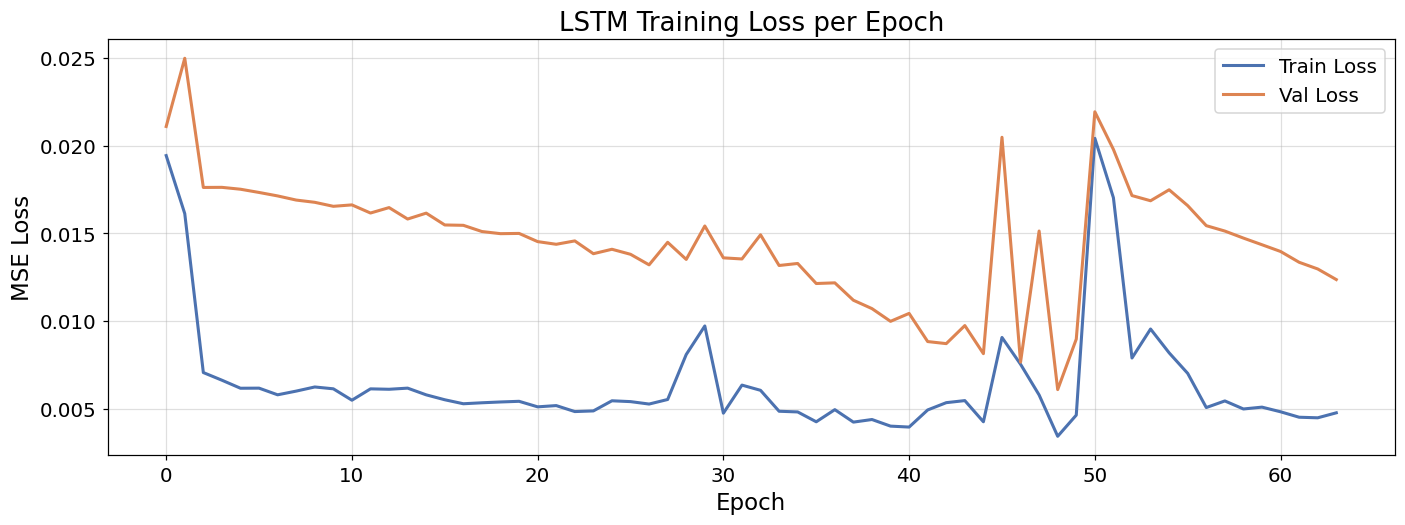

In [ ]:
# LSTM training loss
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(history.history['loss'],     color=C[0], linewidth=2, label='Train Loss')
ax.plot(history.history['val_loss'], color=C[1], linewidth=2, label='Val Loss')
ax.set_title('LSTM Training Loss per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

LSTM                            MAE=35.8  RMSE=46.5  MAPE=7.37%


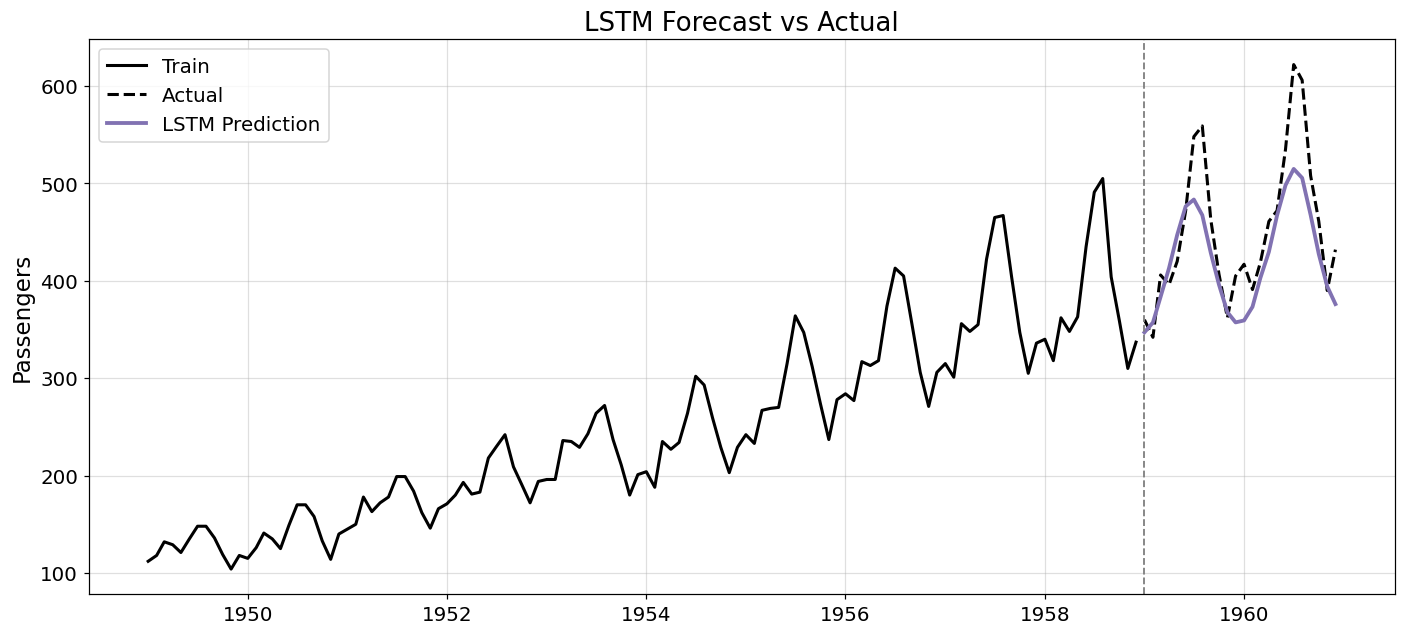

In [ ]:
# LSTM forecast
lstm_pred = scaler.inverse_transform(model.predict(Xte_l, verbose=0)).flatten()
test_idx  = df.index[-24:]
lstm_pred_s = pd.Series(lstm_pred, index=test_idx)
lstm_actual = df['Passengers'].iloc[-24:]
score('LSTM', lstm_actual, lstm_pred_s)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index, train,        color='black', linewidth=2,   label='Train')
ax.plot(test_idx,    lstm_actual,  color='black', linewidth=2,   label='Actual', linestyle='--')
ax.plot(test_idx,    lstm_pred_s,  color=C[4],    linewidth=2.5, label='LSTM Prediction')
ax.axvline(pd.Timestamp('1959-01'), color='grey', linestyle='--', linewidth=1.2)
ax.set_title('LSTM Forecast vs Actual')
ax.set_ylabel('Passengers')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Model Comparison

In [ ]:
comp = pd.DataFrame(results).T.sort_values('MAPE')
comp.insert(0, 'Rank', range(1, len(comp)+1))
print(comp.to_string())
print(f'\nBest model: {comp.index[0]}  (MAPE = {comp.iloc[0]["MAPE"]:.2f}%)')

                             Rank     MAE    RMSE   MAPE
Holt-Winters Multiplicative     1   28.98   32.49   6.39
Holt-Winters Additive           2   31.08   35.76   6.64
LSTM                            3   35.84   46.47   7.37
SARIMA(1,1,1)(0,1,1)[12]        4   36.14   39.85   7.79
auto_SARIMA                     5   39.43   43.16   8.51
XGBoost                         6   41.31   52.22   8.63
LightGBM                        7   52.61   70.66  10.49
auto_ARIMA(2, 1, 1)             8   81.87  107.84  16.26
ARIMA(2,1,1)                    9   81.87  107.84  16.26
Holt Linear                    10   91.62  115.70  18.41
Simple Exp Smoothing           11  115.25  137.33  23.58

Best model: Holt-Winters Multiplicative  (MAPE = 6.39%)


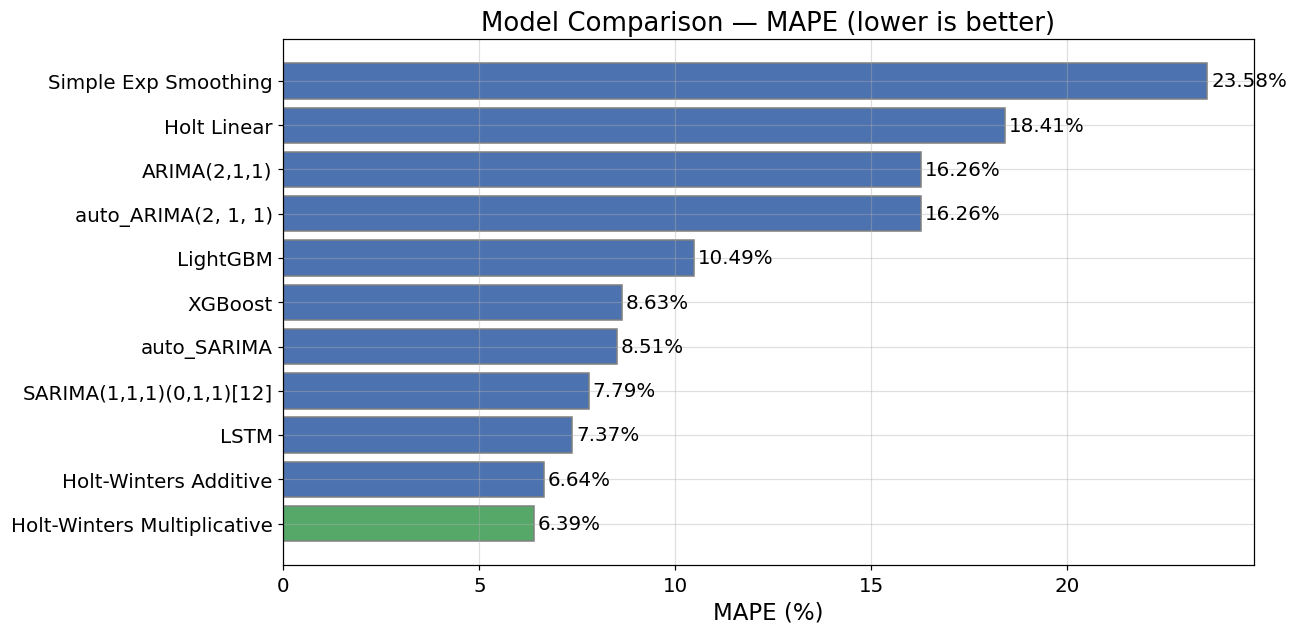

In [ ]:
# MAPE comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = [C[2] if i == 0 else C[0] for i in range(len(comp))]
ax.barh(comp.index, comp['MAPE'], color=colors, edgecolor='grey')
for i, (model, row) in enumerate(comp.iterrows()):
    ax.text(row['MAPE'] + 0.1, i, f"{row['MAPE']:.2f}%", va='center', fontsize=13)
ax.set_title('Model Comparison — MAPE (lower is better)')
ax.set_xlabel('MAPE (%)')
plt.tight_layout()
plt.show()

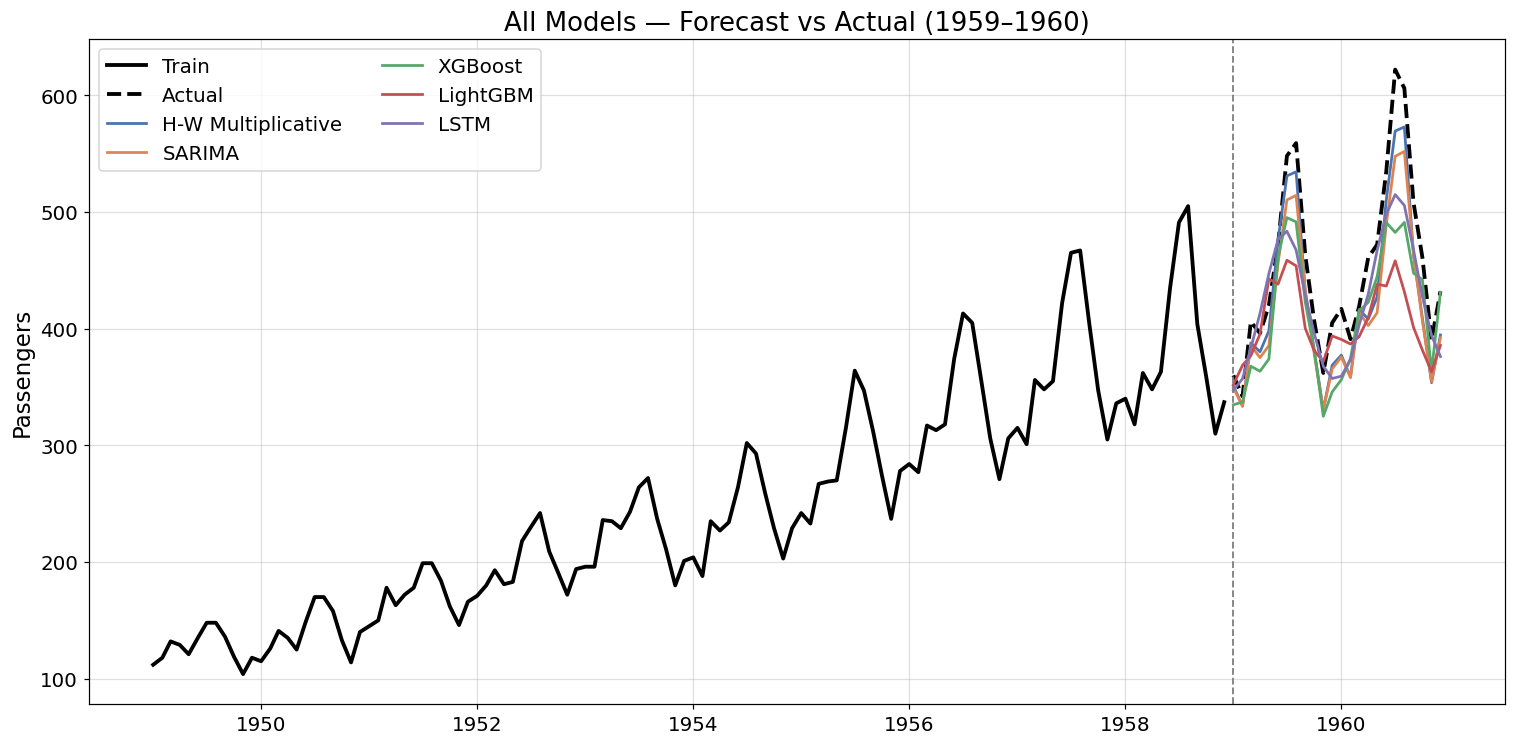

In [ ]:
# All models on one chart
preds = {
    'H-W Multiplicative': hw_m_pred,
    'SARIMA'            : sarima_pred,
    'XGBoost'           : xgb_pred,
    'LightGBM'          : lgb_pred,
    'LSTM'              : lstm_pred_s,
}

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(train.index, train, color='black', linewidth=2.5, label='Train')
ax.plot(test.index,  test,  color='black', linewidth=2.5, label='Actual', linestyle='--')
for i, (name, pred) in enumerate(preds.items()):
    ax.plot(pred.index, pred.values, color=C[i], linewidth=1.8, label=name)
ax.axvline(pd.Timestamp('1959-01'), color='grey', linestyle='--', linewidth=1.2)
ax.set_title('All Models — Forecast vs Actual (1959–1960)')
ax.set_ylabel('Passengers')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## 15. Final 24-Month Forecast (1961–1962)

In [ ]:
# Retrain SARIMA on full data
full_log = np.log(df['Passengers'])
final = SARIMAX(full_log, order=(1,1,1), seasonal_order=(0,1,1,12)).fit(disp=False)

fc       = final.get_forecast(steps=24)
fc_vals  = np.exp(fc.predicted_mean)
fc_ci    = np.exp(fc.conf_int(alpha=0.05))

future_idx    = pd.date_range(start='1961-01', periods=24, freq='MS')
fc_vals.index = future_idx
fc_ci.index   = future_idx

print('Forecast Table (1961–1962):')
print(f'{"Month":<12} {"Forecast":>10} {"Lower 95%":>12} {"Upper 95%":>12}')
print('-' * 50)
for d, v, lo, hi in zip(future_idx, fc_vals, fc_ci.iloc[:,0], fc_ci.iloc[:,1]):
    print(f'{d.strftime("%b %Y"):<12} {v:>10.0f} {lo:>12.0f} {hi:>12.0f}')

Forecast Table (1961–1962):
Month          Forecast    Lower 95%    Upper 95%
--------------------------------------------------
Jan 1961            451          420          484
Feb 1961            427          392          464
Mar 1961            481          438          527
Apr 1961            494          447          546
May 1961            510          458          568
Jun 1961            585          522          655
Jul 1961            672          596          757
Aug 1961            669          590          758
Sep 1961            560          491          638
Oct 1961            498          435          571
Nov 1961            431          374          497
Dec 1961            479          413          554
Jan 1962            497          423          585
Feb 1962            471          396          559
Mar 1962            530          443          634
Apr 1962            544          451          657
May 1962            563          463          684
Jun 1962            6

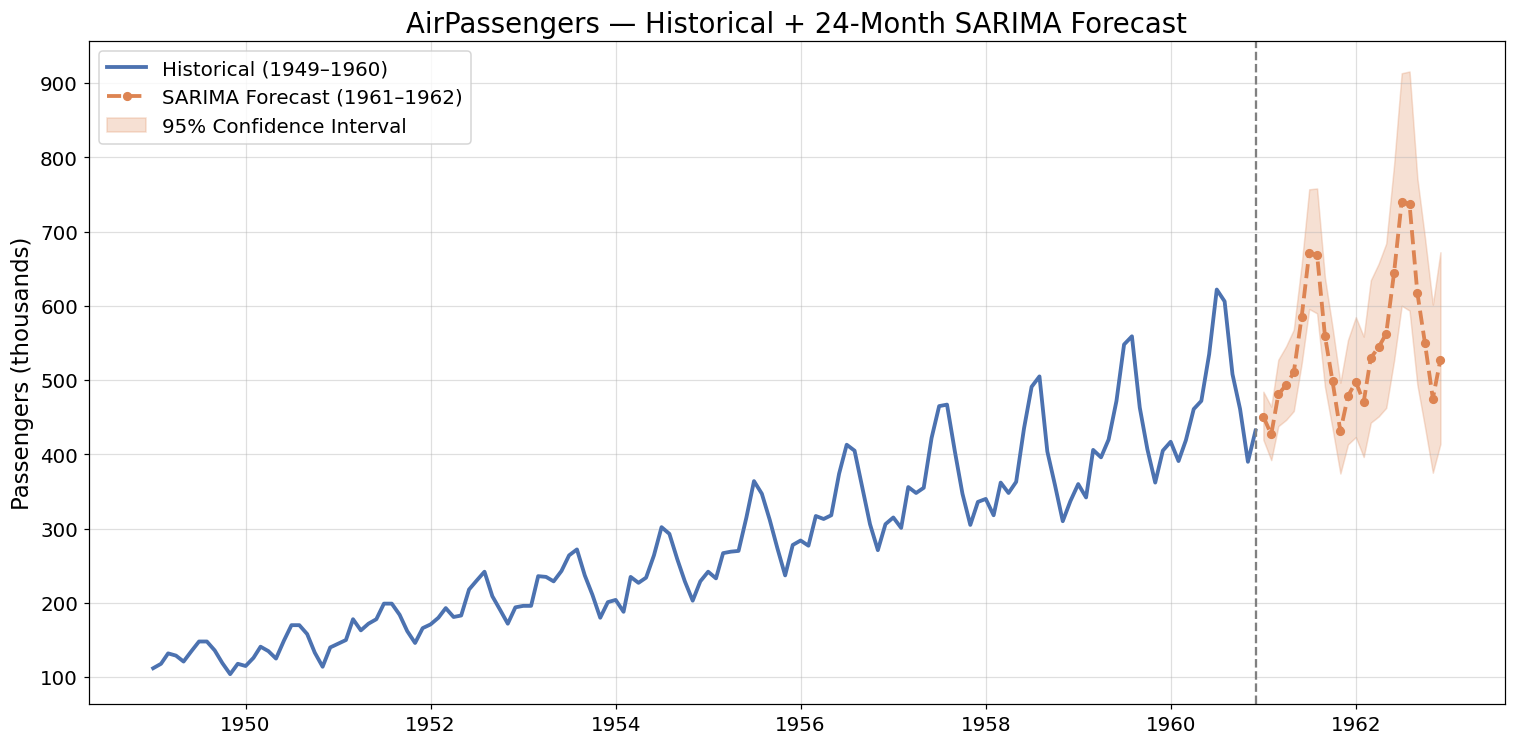

Projected Aug 1962 peak : 740k
Historical Aug 1960 peak: 622k
Projected growth        : +19.0%


In [ ]:
# Final forecast plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df.index,    df['Passengers'],  color=C[0],   linewidth=2.5, label='Historical (1949–1960)')
ax.plot(future_idx,  fc_vals,           color=C[1],   linewidth=2.5,
        linestyle='--', marker='o', markersize=5, label='SARIMA Forecast (1961–1962)')
ax.fill_between(future_idx, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                alpha=0.25, color=C[1], label='95% Confidence Interval')
ax.axvline(df.index[-1], color='grey', linestyle='--', linewidth=1.5)
ax.set_title('AirPassengers — Historical + 24-Month SARIMA Forecast', fontsize=18)
ax.set_ylabel('Passengers (thousands)', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

peak = fc_vals.max()
hist_peak = df['Passengers'].max()
print(f'Projected Aug 1962 peak : {peak:.0f}k')
print(f'Historical Aug 1960 peak: {hist_peak:.0f}k')
print(f'Projected growth        : +{(peak/hist_peak - 1)*100:.1f}%')

## Summary

| Step | What We Did | Key Finding |
|------|-------------|-------------|
| 1 | EDA | 144 monthly records, no missing values |
| 2 | Decomposition | Multiplicative seasonality, strong trend |
| 3 | Stationarity | Non-stationary → fixed by log + D12 + D1 |
| 4 | ACF/PACF | AR(1), MA(1), Seasonal MA(1) |
| 5 | Smoothing | Holt-Winters Multiplicative best smoother |
| 6 | ARIMA | auto_arima picks optimal orders |
| 7 | SARIMA | Best classical model: (1,1,1)(0,1,1)[12] |
| 8 | Feature Eng | Lag, rolling, calendar features |
| 9 | XGBoost/LGB | Tree-based ML with temporal features |
| 10 | LSTM | Deep learning sequence model |
| 11 | Comparison | All models ranked by MAE / RMSE / MAPE |
| 12 | Forecast | 24-month projection with 95% CI |